# neural network for the darcy case

In [ ]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
#from ann_functions3D_noise_fourier import getModel, kCrossVal, transfBestparam, import_data, normalization
#from Multifidelity_support import getModel, kCrossVal, transfBestparam, import_data, normalization, add_noise, MultiFidelity
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from scipy.interpolate import griddata
from time import perf_counter
import pandas
import pickle
import os
from itertools import product
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

: 

In [2]:
# reproducibility
seed=42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data preparation

In [3]:
 
def plot_surface(coord_fine, K):
    # Define grid.
    grid_x, grid_y = np.mgrid[min(coord_fine[:,0]):max(coord_fine[:,0]):complex(0,coord_fine.shape[0]
    ), min(coord_fine[:,1]):max(coord_fine[:,1]):complex(0,coord_fine.shape[0]
    )]

    # Interpolate the data.
    grid_z = griddata((coord_fine[:,0],coord_fine[:,1]), K, (grid_x, grid_y), method='cubic')

    # Create a figure

    fig = plt.figure()

    # Add a 3D subplot
    ax = fig.add_subplot(111, projection='3d')

    # Plot the surface
    surf = ax.plot_surface(grid_x, grid_y, grid_z, cmap='viridis')

    # Add labels
    ax.set_xlabel('X axis')
    ax.set_ylabel('Y axis')
    ax.set_zlabel('Z axis')

    # Add a title
    ax.set_title('3D Surface Plot')

    # Add a color bar which maps values to colors
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

    # Display the plot
    plt.show()



def find_common_rows(arr1, arr2):
    # Ensure input arrays are numpy arrays
    arr1 = np.asarray(arr1)
    arr2 = np.asarray(arr2)
    
    # Convert each row to a tuple of hashable types
    set1 = set(map(tuple, map(tuple, arr1)))
    set2 = set(map(tuple, map(tuple, arr2)))
    
    # Find the intersection of the two sets (common rows)
    common_rows = set1.intersection(set2)
    
    # Convert the common rows back to a list of tuples
    common_rows_list = list(common_rows)
    
    # Find the indices of the common rows in the original arrays
    arr1_indices = np.nonzero([tuple(row) in common_rows for row in map(tuple, arr1)])[0]
    arr2_indices = np.nonzero([tuple(row) in common_rows for row in map(tuple, arr2)])[0]

    return arr1_indices, arr2_indices

In [4]:
with np.load('model_data.npz') as model_data:
    data=model_data['data'] # observations
    datapoints=model_data['datapoints'] # combination of positions condìsidered

    K_coarse=model_data['K_coarse']     
    K_mid=model_data['K_mid']
    K_fine=model_data['K_fine']
    
    coord_coarse=model_data['coord_coarse'] 
    coord_mid=model_data['coord_mid']
    coord_fine=model_data['coord_fine']
    
    noise=model_data['noise']
    theta=model_data['true_parameters_list']   # theta
    x_data=model_data['x_data']
    y_data=model_data['y_data']
    eig=model_data['eig']                                       # eigenvalues
    

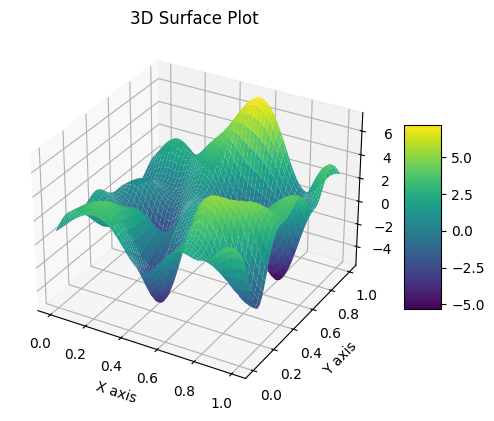

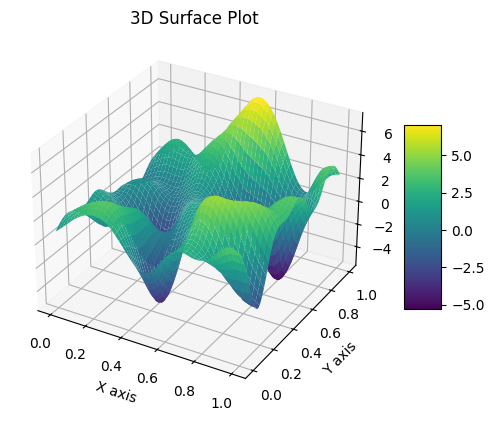

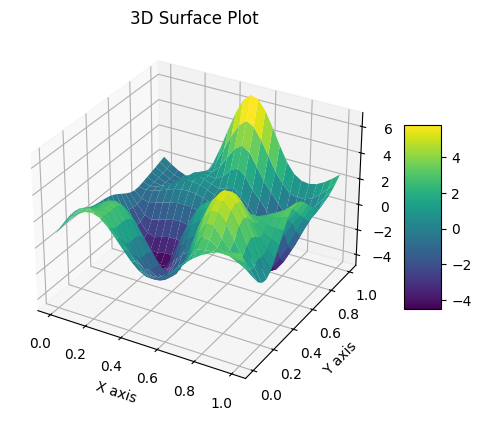

In [5]:
plot_surface(coord_fine[-1],K_fine[-1])
plot_surface(coord_mid[-1],K_mid[-1])
plot_surface(coord_coarse[-1],K_coarse[-1])

In [6]:
coord_coarse_x=np.copy(coord_coarse[:,:,0]).flatten()
coord_coarse_y=np.copy(coord_coarse[:,:,1]).flatten()

coord_mid_x=np.copy(coord_mid[:,:,0]).flatten()
coord_mid_y=np.copy(coord_mid[:,:,1]).flatten()

coord_fine_x=np.copy(coord_fine[:,:,0]).flatten()
coord_fine_y=np.copy(coord_fine[:,:,1]).flatten()

K_fine_copy=np.copy(K_fine).flatten()
K_coarse_copy=np.copy(K_coarse).flatten()
K_mid_copy=np.copy(K_mid).flatten()

theta = np.repeat(theta,repeats=int(K_fine_copy.shape[0]/theta.shape[0]), axis=0)
indexes_mid, _ = find_common_rows(np.stack((coord_mid_x,coord_mid_y),axis=1), np.stack((coord_fine_x,coord_fine_y),axis=1))
indexes_fine,_=find_common_rows(np.stack((coord_fine_x,coord_fine_y),axis=1), np.stack((coord_coarse_x,coord_coarse_y),axis=1))

In [7]:
coord_coarse_x=normalization(coord_coarse_x)
coord_coarse_y=normalization(coord_coarse_y)


K_coarse_norm=normalization(K_coarse_copy)
K_fine_norm=normalization(K_fine_copy)
K_mid_norm=normalization(K_mid_copy)

theta_norm=normalization(theta)

In [8]:
# Number of data of High and Low Fidelity components of the dataset
n_HF = 25
Nlf = 25
Nmf=50

batch_size=[Nlf,Nmf,n_HF]

# number of epochs
Nepo=[7000,7000,8000]



In [9]:
permutation=np.random.permutation(len(coord_coarse_x))

input_c_x=coord_coarse_x[permutation][0:Nlf]
input_c_y=coord_coarse_y[permutation][0:Nlf]
theta_coarse=theta_norm[indexes_fine,:][permutation,:][0:Nlf,:]

K_c=K_coarse_norm[permutation][0:Nlf]
K_c+=np.random.normal(0., 0.1, K_c.shape)
# K_c_test=K_coarse_norm

input_LF=np.c_[input_c_x,input_c_y,theta_coarse]
input_LF_test=np.c_[coord_coarse_x,coord_coarse_y,theta_norm[indexes_fine,:]]

##

permutation_MF=np.random.permutation(len(coord_mid_x))

input_m_x=coord_mid_x[permutation_MF][0:Nmf]
input_m_y=coord_mid_y[permutation_MF][0:Nmf]
theta_mid=theta_norm[indexes_mid,:][permutation_MF,:][0:Nmf,:]

K_m=K_mid_norm[permutation_MF][0:Nmf]
K_m+=np.random.normal(0., 0.05, K_m.shape)
# K_m_test=K_mid_norm

input_MF=np.c_[input_m_x,input_m_y,theta_mid]
input_MF_test=np.c_[coord_mid_x,coord_mid_y,theta_norm[indexes_mid,:]]

##

permutation_HF=np.random.permutation(len(coord_fine_x))

input_f_x=coord_fine_x[permutation_HF][0:n_HF]
input_f_y=coord_fine_y[permutation_HF][0:n_HF]
theta_fine=theta_norm[permutation_HF,:][0:n_HF,:]

K_f=K_fine_norm[permutation_HF][0:n_HF]
K_f+=np.random.normal(0., 0.05, K_f.shape)
# K_m_test=K_mid_norm

input_HF=np.c_[input_f_x,input_f_y,theta_fine]
input_HF_test=np.c_[coord_fine_x,coord_fine_y,theta_norm]




data_train=[input_LF,input_MF,input_HF]
output_train=[K_c,K_m,K_f]
data_test=[input_LF_test,input_MF_test,input_HF_test]
output_test=[K_coarse_norm,K_mid_norm,K_fine_norm]

## Neural Network
Cycle on the Discretization and the value of the diffusion 

In [10]:
# Name of the folder
folder_name = "3_models"
folder_path = os.path.join(os.getcwd(), folder_name)

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")

Folder '3_models' already exists.


In [11]:
test_mse_HF_list = []
test_mse_MF_list = []
test_mse_LF_list = []

r2_HF_list = []    
r2_MF_list = []
r2_LF_list = []


# data_train=[]
# data_test=[]
# output_train=[]
# output_test=[]




The function training took 18.387112379074097 seconds.


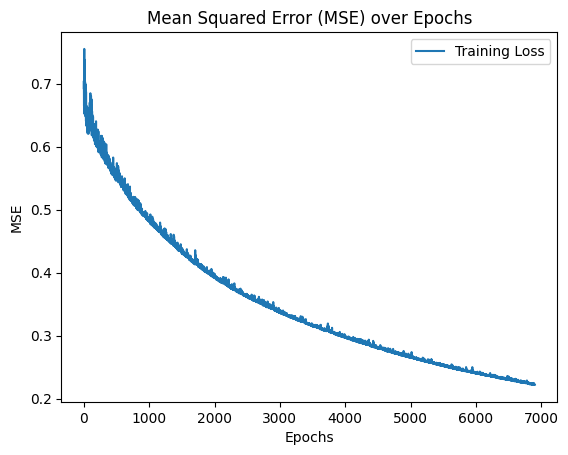

The function training took 14.768044471740723 seconds.


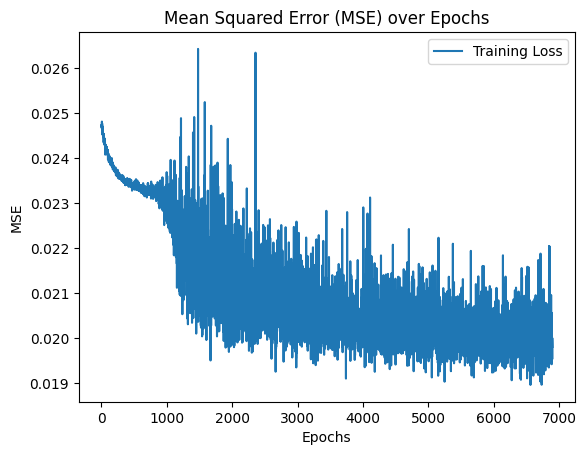

The function training took 18.628525733947754 seconds.


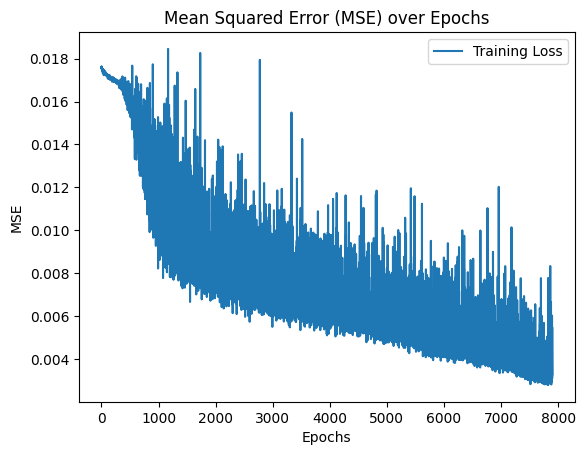

low fidelity 1 NN
Test MSE: 0.03360032631778355
R^2: -0.7967026404048425


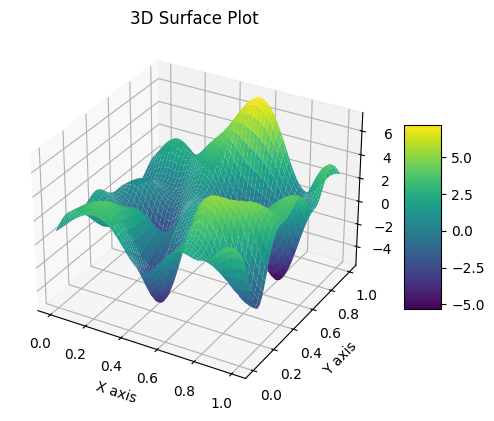

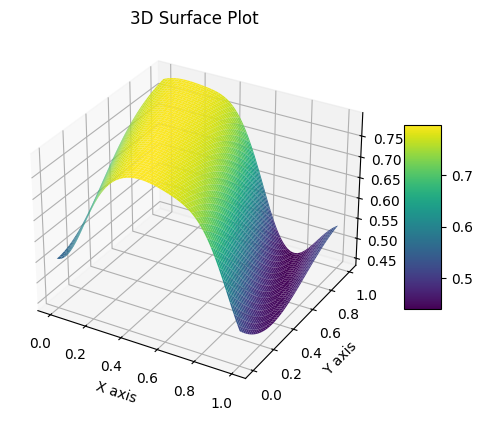

low fidelity 2 NN
Test MSE: 0.020167819863416123
R^2: -0.12360666886546068


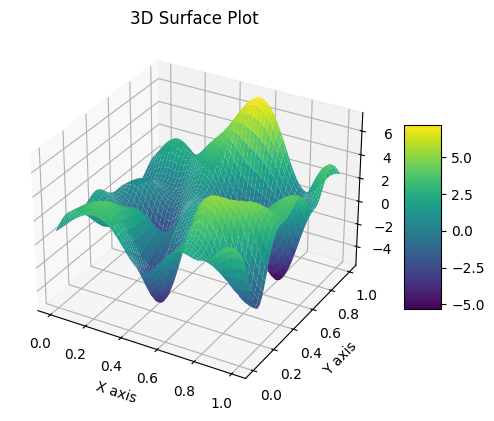

TypeError: Neural_Network.prediction() takes 2 positional arguments but 3 were given

In [12]:
K.clear_session()
best_LF_params = {
        "lr": 0.0255,
        "kernel_init": "glorot_uniform",
        "opt": "Adam",
    }

best_MF_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}
best_HF_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}
names=["LF","HF","HF"]
params=[best_LF_params, best_MF_params, best_HF_params]
data_train_original=copy.deepcopy(data_train)
model= NetworkFactory.build_network("3step",names,params=params,data_train=data_train,output_train=output_train,N=Nepo,n=batch_size,do_HPO=False,verbose=True)


# first network

ULF = model.model_list[0].prediction(data_test[0])
print("low fidelity 1 NN")

(test_mse_LF,r2_LF) = model.model_list[0].performance(data_test[0],output_test[0])
test_mse_LF_list.append(test_mse_LF)
r2_LF_list.append(r2_LF)

# plt.figure()
# plt.plot(
# data_test[0], output_test[0], "y-", linewidth=1.5, label="LF model"
# )
# plt.plot(
# data_train[0],
# output_train[0],
# "yo",
# markersize=5,
# label="LF training points",
# )
# plt.plot(
# data_test[0],
# ULF,
# "g-",
# linewidth=3,
# label="Predicted LF model",
# )
# plt.legend(prop={"size": 8.3})
# plt.show()


plot_surface(coord_fine[-1],K_fine[-1])
plot_surface(coord_fine[-1],model.model_list[0].prediction(np.c_[normalization(coord_fine)[-1][:,0],normalization(coord_fine)[-1][:,1],theta_norm[-normalization(coord_fine[-1][:,0]).shape[0]:,:]])[:,0])


# second network
input_MF = np.concatenate(
    (data_test[1],  model.model_list[0].prediction(data_test[1]).reshape(-1,1)),axis=1
)  # <- TRAINING INPUT for the second NN: NN_HF   


input_HF = np.concatenate(
    (data_test[2],  model.model_list[0].prediction(data_test[2]).reshape(-1,1)),axis=1
)  # <- TRAINING INPUT for the second NN: NN_HF  

# training component of the dataset (for each NN)
input_MF_train = np.concatenate(
    (data_train_original[1],  model.model_list[0].prediction(data_train_original[1]).reshape(-1,1)),axis=1
) 



input_HF_train = np.concatenate(
    (data_train_original[2],  model.model_list[0].prediction(data_train_original[2]).reshape(-1,1)),axis=1
) 

ULF2 = model.model_list[1].prediction(input_MF)
print("low fidelity 2 NN")

(test_mse_MF,r2_MF) = model.model_list[1].performance(input_MF,output_test[1])
test_mse_MF_list.append(test_mse_MF)
r2_MF_list.append(r2_MF)

# plt.figure()
# plt.plot(
# data_test[1], output_test[1], "y-", linewidth=1.5, label="LF model"
# )
# plt.plot(
# data_train_original[1],
# output_train[1],
# "yo",
# markersize=5,
# label="LF training points",
# )
# plt.plot(
# data_test[1],
# ULF2,
# "g-",
# linewidth=3,
# label="Predicted LF model",
# )
# plt.legend(prop={"size": 8.3})
# plt.show()

plot_surface(coord_fine[-1],K_fine[-1])
plot_surface(coord_fine[-1],model.model_list[1].prediction(np.c_[normalization(coord_fine)[-1][:,0],normalization(coord_fine)[-1][:,1]],model.model_list[0].prediction(np.c_[normalization(coord_fine)[-1][:,0],normalization(coord_fine)[-1][:,1],theta_norm[-normalization(coord_fine[-1][:,0]).shape[0]:,:]]))[:,0])


# third network 

input_LF3 = np.concatenate(
    (input_LF3,  model.model_list[1].prediction(input_LF3).reshape(-1,1)),axis=1
)  # <- TRAINING INPUT for the second NN: NN_HF

input_HF = np.concatenate(
    (input_HF,  model.model_list[1].prediction(input_HF).reshape(-1,1)),axis=1
)  # <- TRAINING INPUT for the second NN: NN_HF   

input_LF3_train = np.concatenate(
    (input_LF3_train,  model.model_list[1].prediction(input_LF3_train).reshape(-1,1)),axis=1
) 

input_HF_train = np.concatenate(
    (input_HF_train,  model.model_list[1].prediction(input_HF_train).reshape(-1,1)),axis=1
) 

ULF3 = model.model_list[2].prediction(input_LF3)
print("low fidelity 3 NN")

(test_mse_LF,r2_LF) = model.model_list[2].performance(input_LF3,output_test[2])
test_mse_LF_list.append(test_mse_LF)
r2_LF_list.append(r2_LF)

plt.figure()
plt.plot(
data_test[2], output_test[2], "y-", linewidth=1.5, label="LF model"
)
plt.plot(
data_train_original[2],
output_train[2],
"yo",
markersize=5,
label="LF training points",
)
plt.plot(
data_test[2],
ULF3,
"g-",
linewidth=3,
label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

# continua in questo modo e runna


In [ ]:
model.model_list[0].prediction(np.c_[normalization(coord_fine[-1][:,0]),normalization(coord_fine[-1][:,1]),theta_norm[-normalization(coord_fine[-1][:,0]).shape[0]:,:]])

array([[0.78182095],
       [0.7806492 ],
       [0.7848497 ],
       ...,
       [0.53235817],
       [0.51027876],
       [0.5159857 ]], dtype=float32)

In [ ]:
K_fine[-1].shape

(4225,)

In [ ]:
model.model_list[0].prediction(np.c_[normalization(coord_fine[-1][:,0]),normalization(coord_fine[-1][:,1]),theta_norm[-normalization(coord_fine[-1][:,0]).shape[0]:,:]])[:,0]

array([0.78182095, 0.7806492 , 0.7848497 , ..., 0.53235817, 0.51027876,
       0.5159857 ], dtype=float32)

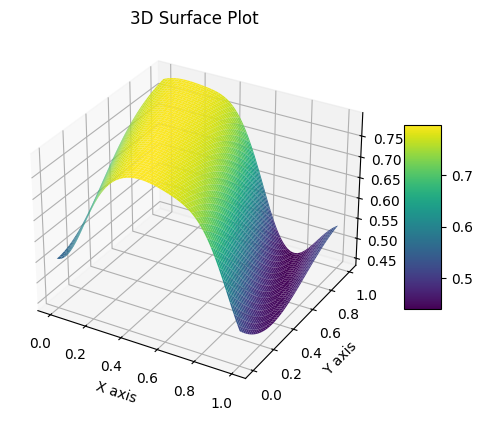

In [ ]:
plot_surface(coord_fine[-1],model.model_list[0].prediction(np.c_[normalization(coord_fine[-1][:,0]),normalization(coord_fine[-1][:,1]),theta_norm[-normalization(coord_fine[-1][:,0]).shape[0]:,:]])[:,0])


In [ ]:
normalization(coord_fine[-1][:,0]).shape

(4225,)

In [ ]:
theta_norm[-1].shape

(64,)

In [ ]:
theta_norm.shape

(42250, 64)

In [ ]:
theta_norm[-normalization(coord_fine[-1][:,0]).shape[0]:,:]

array([[0.23876998, 0.52184781, 0.42476487, ..., 0.49433026, 0.42901767,
        0.20606755],
       [0.23876998, 0.52184781, 0.42476487, ..., 0.49433026, 0.42901767,
        0.20606755],
       [0.23876998, 0.52184781, 0.42476487, ..., 0.49433026, 0.42901767,
        0.20606755],
       ...,
       [0.23876998, 0.52184781, 0.42476487, ..., 0.49433026, 0.42901767,
        0.20606755],
       [0.23876998, 0.52184781, 0.42476487, ..., 0.49433026, 0.42901767,
        0.20606755],
       [0.23876998, 0.52184781, 0.42476487, ..., 0.49433026, 0.42901767,
        0.20606755]])